# Using the BOSS Visual Inspection VAC 

## Learning Goals
By the end of this tutorial, you will:
- Understand how to access the redshift and redshift quality information provided by the BOSS Visual Inspection Value Added Catalog (SDSS-V VAC 0037)
- Know how to join this information to spectroscopic summary files produced by the BOSS pipeline
- Understand how to select a sub-sample of spectra based on these files

## Introduction

The pipeline used to determine redshifts from BOSS spectra (idlspec1d) is highly reliable. However, we observed a small but significant fraction of cases in which the fitted redshifts are incorrect. This is sometimes due to data quality issues (low SNR, poor sky subtraction, reduction artefacts etc), and sometimes due to objects having spectral shapes that are poorly represented by the spectral templates, and/or lacking in strong features. To increase the reliability of redshifts in BHM science samples, we have conducted a dedicated program of visual inspection of DR20 BOSS spectra. A team of more than 20 volunteers has carried out inspections via a dedicated web app (previously used for inspecting SDSS spectra in the eFEDS field). For practical reasons, we were able to inspect only a small fraction (~20k) of the ~500k DR20 'allepoch' coadded BOSS spectra, focusing efforts on carefully selected subset of spectra expected to have the highest failure rates but enough signal to determine redshifts by eye. This is supplemented with visually inspected redshift information extracted from DR16Q. This VAC provides a row-matched supplement to the DR20 allepoch spAll file. For each entry, we flag if the source has been visually inspected, the redshift from the visual inspection, the redshift confidence, and the visual classification. In addition,  using the visually inspected spectra as a training sample, we developed a machine learning classifier which uses features from the spAll catalog to predict if the pipeline redshifts are expected to be reliable or not. Information from visual inspections and the ML classifier are combined to attach a good/bad flag to each entry in the VAC.

SDSS-V VAC 0037 is presented here: https://www.sdss.org/dr20/data_access/value-added-catalogs/?vac_id=10037

In this short tutorial we will show how to combine the information in the VAC 0037 with other SDSS-V data files in order to examine failure cases, and then how to select a reliable sub-sample of spectra.

### Imports
This tutorial requires several commonly used python packages, and an SDSS specific package

TODO

- `numpy` for doing large array operations
- `scipy` for 2d data statistics operations
- `matplotlib` for plotting
- `astropy` for reading fits files and tables (and optionally used to download the supplemental files)
- `os` used for accessing environmental variables (optinal if not using astropy to download the supplemental files)
- `sdss_access` for download the sdss data and building the file paths (this can be manually down if desired, but this is not shown here)
- `random` for generating a random choice

Missing packages can be installed via `pip install numpy matplotlib scipy astropy sdss-access`

#### **Note!**
If you already have `sdss_access` installed but have trouble with these file types, try upgrading to the latest version `pip install --upgrade sdss-access sdss-tree`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mpl_colors
from astropy.table import Table, join
from astropy.io import fits
from scipy.stats import binned_statistic_2d
from random import randrange

from sdss_access import Access, path
sdss_path = path.Path(release='dr20', verbose=True)
access = Access(release='dr20', verbose=False)

run2d = 'v6_2_1' # The Run2d version of the BOSS Pipeline used for DR20
flav = 'spAll-lite_coadd' # the BOSS summary file to consider
coadd = 'allepoch' # the BOSS coadd type to consider
vac_name = 'boss_vi_results' # the label in sdss_access for the VAC data file
v_vac = '1.0.3' # the version of the VAC to use



## Downloading local copies of BOSS VI VAC and BOSS Summary file 

NB see https://sdss-access.readthedocs.io/en/latest/path_defs.html#dr20 for alternative versions of BOSS pipeline products



## Download a local copy of the BOSS Summary file

The spAll-lite_coadd file is a summary of the spectroscopic information available for all spectra within this coadding scheme.

If running on SciServer, skip this step and move to the "access.full" commands to load the data.

In [2]:
spAll_file = sdss_path.full(flav, run2d=run2d, coadd=coadd)

if not sdss_path.exists('',full=spAll_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add(flav, run2d=run2d, coadd=coadd)
    access.set_stream()
    access.commit()
    spAll_file = sdss_path.full(flav, run2d=run2d, coadd=coadd)


## Download a local copy of the BOSS VI VAC file



In [3]:
vac_file = sdss_path.full(vac_name, v_vac=v_vac)

if not sdss_path.exists('',full=vac_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add(vac_name, v_vac=v_vac)
    access.set_stream()
    access.commit()
    spAll_file = sdss_path.full(vac_name, v_vac=v_vac)


In this example we will use the summary file associated with the 'allepoch' coadds, but can replaced with the 'daily' or Field 'epoch' coadds instead

In [4]:
spAll_file = access.full(flav, run2d=run2d, coadd=coadd)

access.exists('', full=spAll_file)

True

In [5]:
vac_file = access.full(vac_name, v_vac=v_vac)

access.exists('', full=vac_file)

True

In [6]:
spAll = Table.read(spAll_file)
vac = Table.read(vac_file)

## Join the tables via unique identifier


In [7]:
j = join(spAll, vac, 
         keys_left='CATALOGID', 
         keys_right='catalogid', 
         join_type='left', 
         # table_names=["", "_vi"],
         metadata_conflicts='silent')

print(f"There are {len(j)} rows in the joined table")

There are 506550 rows in the joined table


## Define some sub-samples

In [8]:
## Select a clean subsample
'''
Select a clean subsample that have secure redshifts, either from visual inspections, 
or from the pipeline (with support from the ML classifier)  
'''
gm = np.where(j['z_best_reliable'], True, False)


# cases where the visual inspections determined that the pipeline redshift is wrong or unreliable
bvim = np.where(j['has_vi'] & ~gm, True, False)

# cases where the Machine Learning classifier determined that the pipeline redshift is unreliable
bmlm = np.where(~j['has_vi'] & ~gm, True, False)


print(
    f"In total there are {len(j)} rows in the joined table.\n"
    f"There are {np.count_nonzero(gm)} rows with reliable redshifts.\n"
    f"There are {np.count_nonzero(~gm)} rows where we expect best redshift is wrong and/or unreliable.\n"
    f"Of which, {np.count_nonzero(bvim)} cases are directly from visual inspection, \n"
    f"and {np.count_nonzero(bmlm)} cases are from the ML classifier (trained on the VI results)."
)



In total there are 506550 rows in the joined table.
There are 448449 rows with reliable redshifts.
There are 58101 rows where we expect best redshift is wrong and/or unreliable.
Of which, 4418 cases are directly from visual inspection, 
and 53683 cases are from the ML classifier (trained on the VI results).


## Examine the parameter space in which the pipeline redshifts are most/least reliable 

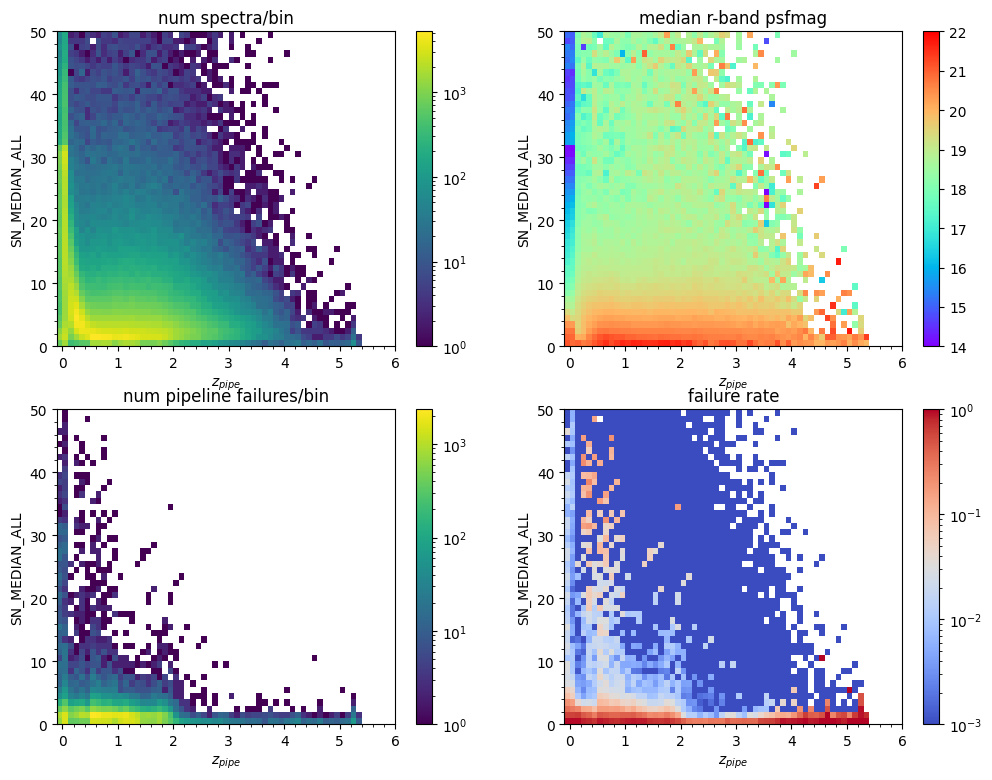

In [9]:

x0 = j['Z']
y0 = j['SN_MEDIAN_ALL']
w0 = j['PSFMAG'][:,2]

x2 = j[~gm]['Z']
y2 = j[~gm]['SN_MEDIAN_ALL']


nxybins = (61, 50)

xyrange = [[-0.1,6.0], [0,50]]
counts0, xbins, ybins = np.histogram2d(x0, y0, bins=nxybins, range=xyrange)
counts2, _, _ = np.histogram2d(x2, y2, bins=(xbins, ybins))
# cmask0 = np.where(counts0 > 0, True, False)

means0, _, _, _ = binned_statistic_2d(x0, y0, w0, statistic='mean', bins=(xbins, ybins))
with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    medians0, _, _, _ = binned_statistic_2d(x0, y0, w0, statistic='median', bins=(xbins, ybins))

  
with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    ratios = np.divide(counts2, counts0)    
    ratios = np.nan_to_num(ratios, copy=True, nan=0.0, posinf=1.0, neginf=1.0)
    ratios = np.clip(ratios, 1e-3, 1)
    ratios = np.where(counts0 == 0, 0, ratios)
    
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(12, 9))
with np.errstate(divide='ignore', invalid='ignore'):
    m1 = ax1.pcolormesh(xbins, ybins, counts0.T, cmap='viridis', norm=mpl_colors.LogNorm())
    m2 = ax2.pcolormesh(xbins, ybins, medians0.T, cmap='rainbow', vmin=14, vmax=22)
    m3 = ax3.pcolormesh(xbins, ybins, counts2.T, cmap='viridis', norm=mpl_colors.LogNorm())
    m4 = ax4.pcolormesh(xbins, ybins, ratios.T, cmap='coolwarm',  
                        norm=mpl_colors.LogNorm())

plt.colorbar(m1, ax=ax1)
plt.colorbar(m2, ax=ax2)
plt.colorbar(m3, ax=ax3)
plt.colorbar(m4, ax=ax4)
ax1.set_title('num spectra/bin')
ax2.set_title('median r-band psfmag')
ax3.set_title('num pipeline failures/bin')
ax4.set_title('failure rate')
for ax in [ax1,ax2,ax3,ax4]:
    ax.set_xlabel(r'$z_{pipe}$')
    ax.set_ylabel('SN_MEDIAN_ALL')
    ax.minorticks_on()
    
    
    

As expected, there is a higher than average failure rate when the spectra have low SNR. In addition, there are particular redshift ranges which show an enhanced failure rate.

## Illustrate cases where Visual Inspection corrected the pipeline redshift

In [10]:
# cases where the pipeline redshift is off by more than 1%, as determined by VI
with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
    j['zfracdiff'] = np.divide(np.abs(j['z_vi'] - j['Z']), 
                              np.maximum(0, j['z_vi']) + 1.0) 
    zbm = np.where(j['has_vi'] &
                   (j['z_conf_vi'] == 3) &
                   (j['zfracdiff'] > 0.01), 
                   True, False)

print(f"There are {np.count_nonzero(zbm)} spectra where VI gives a confident redshift\n"
      "and prefers a significantly different redshift to the pipeline.")




There are 6221 spectra where VI gives a confident redshift
and prefers a significantly different redshift to the pipeline.


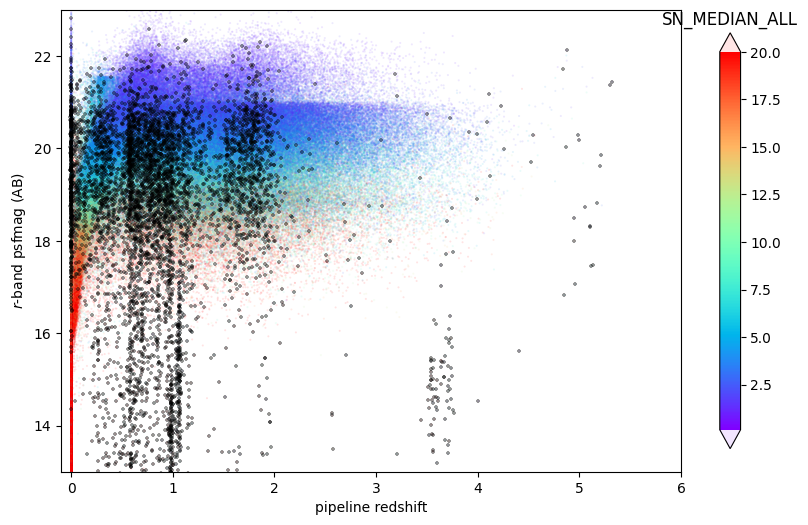

In [11]:
fig = plt.figure(figsize=(10,6))

x1  = j[gm]['Z']
y1 = j[gm]['PSFMAG'][:,2]
c1 = np.clip(j[gm]['SN_MEDIAN_ALL'], 0, 20)
sct = plt.scatter(
    x1, y1, c=c1,
    marker='.', 
    s=1,
    alpha=0.1,
    cmap='rainbow',
)

x2  = j[zbm]['Z']
y2 = j[zbm]['PSFMAG'][:,2],
plt.scatter(
    x2, y2, c='black',
    marker='+', 
    s=5,
    alpha=0.4,
    )

plt.xlim([-0.1, 6])
plt.ylim([13, 23])

cbar = fig.colorbar(sct, location='right', shrink=0.9, extend='both', alpha=1)
cbar.ax.set_title('SN_MEDIAN_ALL')
cbar.solids.set(alpha=1)
    
plt.xlabel('pipeline redshift')
plt.ylabel(r'$r$-band psfmag (AB)')
plt.show()

## Select some examples of high redshift failures from the parameter space identified above


In [12]:
# identify a sample of relatively bright failure cases
xm = np.where(zbm & 
              (j['Z']>0.8) & 
              (j['Z']<1.0) & 
              (j['PSFMAG'][:,2]>17) & 
              (j['PSFMAG'][:,2]<18) &
              (j['z_vi'] > 0.1) & 
              (j['SN_MEDIAN_ALL'] > 5.0)) 


print(f"This filter selects {np.count_nonzero(xm)} rows")


print(j[xm]['catalogid', 'OBS', 'MJD', 'Z', 'z_vi', 'SN_MEDIAN_ALL'])


This filter selects 46 rows
    catalogid     OBS  MJD      Z         z_vi   SN_MEDIAN_ALL
----------------- --- ----- ---------- --------- -------------
63050394818045015 APO 60374  0.9146277 0.7666527      10.25476
63050394820032992 APO 60381  0.8312892 0.6938759     14.878837
63050394821569184 APO 59222  0.8785859   1.50496     37.818462
63050394849666596 APO 59340 0.88472396 0.7436498      33.40617
63050394849892485 APO 59392  0.9147056     1.293     47.887768
63050394850131123 APO 60691 0.93060416       2.0     6.0718384
63050394851324772 APO 60661  0.8893483     1.605     10.233512
63050394852146185 APO 60380  0.8130477   1.47954      62.33254
63050394852343533 APO 60295 0.95855886 0.5528792     15.279085
63050394961598443 APO 59357 0.84594095  2.532435      22.48117
              ... ...   ...        ...       ...           ...
63050395811131010 LCO 60631  0.8042962  0.668788      9.822879
63050395812349593 LCO 60652  0.8839888 0.7377491     11.203353
63050395940409838 LCO 60695


## Retrieving and plotting the spectra for failure cases

If running on SciServer, comment out the `access` lines in this cell and move to the "access.full" commands to load the data.

In [13]:
# choose a random spectrum from the list above
i = randrange(0, len(j[xm]) -1)
s = j[xm][i]

specFile = access.full('specLite_coadd', run2d=run2d, obs=s['OBS'], 
                       mjd=s['MJD'], catalogid=s['CATALOGID'], coadd=coadd)

print(specFile)

if not access.exists('',full=specFile):
    access.remote()
    # Allepoch Spectra
    access.add('specLite_coadd', run2d=run2d, obs=s['OBS'], 
                       mjd=s['MJD'], catalogid=s['CATALOGID'], coadd=coadd)
    access.set_stream()
    access.commit()
    access.reset()

/mypool/sdss/sas/dr20/spectro/boss/redux/v6_2_1/spectra/allepoch/lite/allepoch/allepoch_apo/59357/spec-allepoch_apo-59357-63050394961598443.fits


Progress: 100%|███████████████████████████████████| 1/1 [00:05<00:00,  5.00s/files, n_files=1, n_streams=1]

SDSS_ACCESS> Done!


In [14]:
spectra = fits.getdata(specFile, 'COADD')
spAll = fits.getdata(specFile,'SPALL')

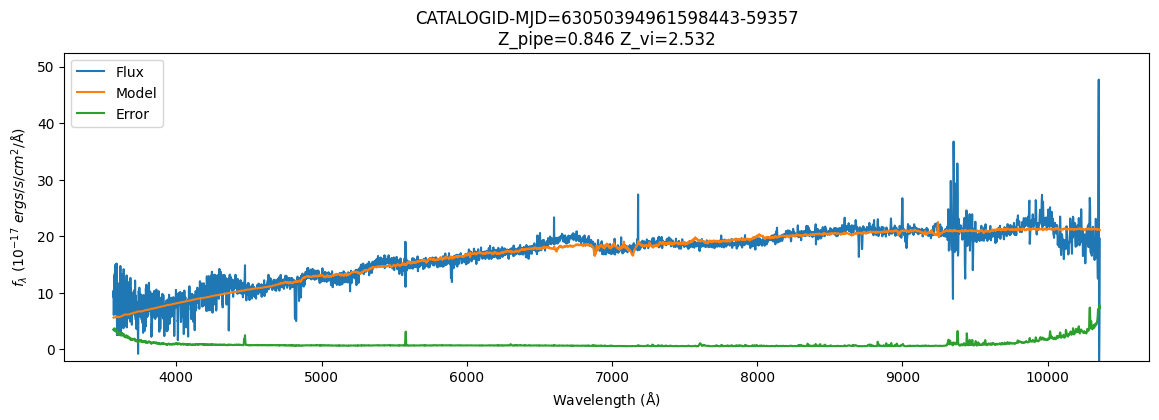

In [15]:
plt.figure(figsize=(14,4))
wave = np.power(10, spectra['LOGLAM'])
mask = (spectra['AND_MASK'] == 0)
plt.plot(wave[mask], spectra['FLUX'][mask], label ='Flux')
plt.plot(wave[mask], spectra['MODEL'][mask], label= 'Model')
error = np.full_like(spectra['IVAR'].data, np.nan)
error[spectra['IVAR'] > 0]  = 1.0/np.sqrt(spectra['IVAR'][spectra['IVAR'] > 0])
plt.plot(wave[mask], error[mask], label='Error')
plt.ylim(np.min(spectra['FLUX'][mask][np.where(wave[mask]>3800)[0]]),
         1.1*np.max(spectra['FLUX'][mask][np.where(wave[mask]>3800)[0]]))
plt.ylabel(r'$f_\lambda~(10^{-17}~ergs/s/cm^2/\mathrm{\AA})$')
plt.xlabel(r'Wavelength $(\mathrm{\AA})$')
plt.title(f'CATALOGID-MJD={s["CATALOGID"]}-{s["MJD"]}\n'
          f'Z_pipe={s["Z"]:.3f} Z_vi={s["z_vi"]:.3f}')
plt.legend()
plt.show()

## Select a sample of science spectra that meet various criteria

Here we select a reliable sample of intermediate redshift (1 < z < 2) QSOs within the magnitude range 17 < i_psfmag < 20, having spectra with reasonable SNR (>5 per pixel), using the information from VAC0037 to remove objects with unreliable redshifts. 


In [16]:
# j.colnames

In [17]:
sm = np.where(j['z_best_reliable'] &
              (j['class_best'] == 'QSO') &
              (j['z_best']>1.0) & 
              (j['z_best']<2.0) & 
              (j['PSFMAG'][:,3]>17) & 
              (j['PSFMAG'][:,3]<20) &
              (j['SN_MEDIAN_ALL'] > 5.0),
              True, False)

print(f"These criteria select {np.count_nonzero(sm)} objects")


These criteria select 41703 objects


## About this notebook

**Authors**: Tom Dwelly, with spectral plotting code copied from Sean Morrison

**Last Update**: 2026 June 18

If you use astropy for published research, please cite the authors. Follow this link for more information about citing astropy: [Citing `astropy`](https://www.astropy.org/acknowledging.html) 

And of course please [cite](https://sdss.org/collaboration/citing-sdss/) SDSS when you use our data.